# Tarea 2 - Estadística II
## Modelos de Regresión aplicados a la base de datos ICFES SB11-2023-1

**Autores:** [Carlos Andres Martinez Vergara, Danilo Andres Ramirez Rey, Jhon Davide Peña Romero, Juan Jose Bautista Roldan]  
**Universidad Industrial de Santander**

### Contexto de los datos
La base de datos `SB11_20231.TXT` contiene los resultados de la prueba Saber 11 del ICFES correspondiente al primer corte del año 2023. Esta prueba evalúa las competencias de los estudiantes de último grado de educación media en Colombia en cinco áreas: Lectura Crítica, Matemáticas, Ciencias Naturales, Sociales y Ciudadanas, e Inglés. Adicionalmente, contiene la variable `ESTU_INSE_INDIVIDUAL`, un Índice de Nivel Socioeconómico construido por el ICFES a partir de variables del cuestionario socioeconómico (educación de los padres, ingresos, bienes del hogar, etc.).

### Objetivo
Construir modelos de regresión (lineal múltiple y red neuronal MLP) que permitan **imputar** el nivel socioeconómico (`ESTU_INSE_INDIVIDUAL`) de los estudiantes a partir de sus puntajes en las cinco áreas evaluadas.

In [ ]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
uploaded = files.upload()

Saving SB11_20231.TXT to SB11_20231.TXT


In [ ]:
bites = io.BytesIO(uploaded['SB11_20231.TXT'])
datos_icfes = pd.read_csv(io.BytesIO(uploaded['SB11_20231.TXT']) ,
delimiter='¬', engine='python')

print("Dimensiones:", datos_icfes.shape)
datos_icfes.head()


Dimensiones: (12704, 83)


,ESTU_TIPODOCUMENTO,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,PERIODO,ESTU_CONSECUTIVO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_DEPTO,...,PUNT_INGLES,PERCENTIL_INGLES,DESEMP_INGLES,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,PERCENTIL_ESPECIAL_GLOBAL,ESTU_ESTADOINVESTIGACION
0,TI,COLOMBIA,F,04/11/2005,20231,SB11202310019049,ESTUDIANTE,COLOMBIA,CUNDINAMARCA,25,...,87.0,94.0,B+,422,100.0,67.532814,4.0,4,100.0,PUBLICAR
1,TI,COLOMBIA,M,08/04/2007,20231,SB11202310017318,ESTUDIANTE,COLOMBIA,VALLE,76,...,NaN,NaN,NaN,326,NaN,47.223972,2.0,3,100.0,PUBLICAR
2,TI,COLOMBIA,F,26/05/2006,20231,SB11202310030916,ESTUDIANTE,COLOMBIA,VALLE,76,...,NaN,NaN,NaN,186,NaN,67.695519,4.0,3,40.0,PUBLICAR
3,CC,COLOMBIA,F,24/05/2004,20231,SB11202310074169,ESTUDIANTE,COLOMBIA,VALLE,76,...,58.0,43.0,A2,200,12.0,41.863163,2.0,3,58.0,PUBLICAR
4,TI,COLOMBIA,F,04/05/2005,20231,SB11202310044933,ESTUDIANTE,COLOMBIA,VALLE,76,...,69.0,57.0,B1,263,39.0,51.223795,3.0,3,92.0,PUBLICAR


## 1. Eliminación de valores faltantes

Para los modelos de regresión necesitamos observaciones completas en las seis
variables de interés. Eliminamos cualquier registro con `NaN` en al menos una de
ellas

In [ ]:
# Conjunto sin NaN en ninguna de las variables de interés
icfes_sin_nan = datos_icfes[(~datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
                            (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
                            (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
                            (~datos_icfes['PUNT_C_NATURALES'].isna()) &
                            (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
                            (~datos_icfes['PUNT_INGLES'].isna())]

print(f"Registros originales: {len(datos_icfes)}")
print(f"Registros sin NaN:    {len(icfes_sin_nan)}")
print(f"Porcentaje conservado: {100*len(icfes_sin_nan)/len(datos_icfes):.2f}%")

# Estadísticos descriptivos
variables = ['ESTU_INSE_INDIVIDUAL', 'PUNT_LECTURA_CRITICA', 'PUNT_MATEMATICAS',
             'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_INGLES']
icfes_sin_nan[variables].describe()

Registros originales: 12704
Registros sin NaN:    11853
Porcentaje conservado: 93.30%


,ESTU_INSE_INDIVIDUAL,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
count,11853.000000,11853.000000,11853.000000,11853.000000,11853.000000,11853.000000
mean,63.009099,64.618493,64.227622,61.198937,61.021092,73.110689
std,7.425760,9.227580,11.841611,10.219639,11.063674,13.933169
min,23.416927,25.000000,16.000000,27.000000,24.000000,26.000000
25%,58.187168,59.000000,57.000000,55.000000,54.000000,64.000000
50%,63.989899,66.000000,65.000000,62.000000,62.000000,77.000000
75%,68.541442,71.000000,72.000000,69.000000,69.000000,82.000000
max,83.007321,100.000000,100.000000,100.000000,100.000000,100.000000


## 2. Selección de variables explicativas mediante diagramas de dispersión

Visualizamos la relación entre `ESTU_INSE_INDIVIDUAL` y
cada uno de los cinco puntajes.

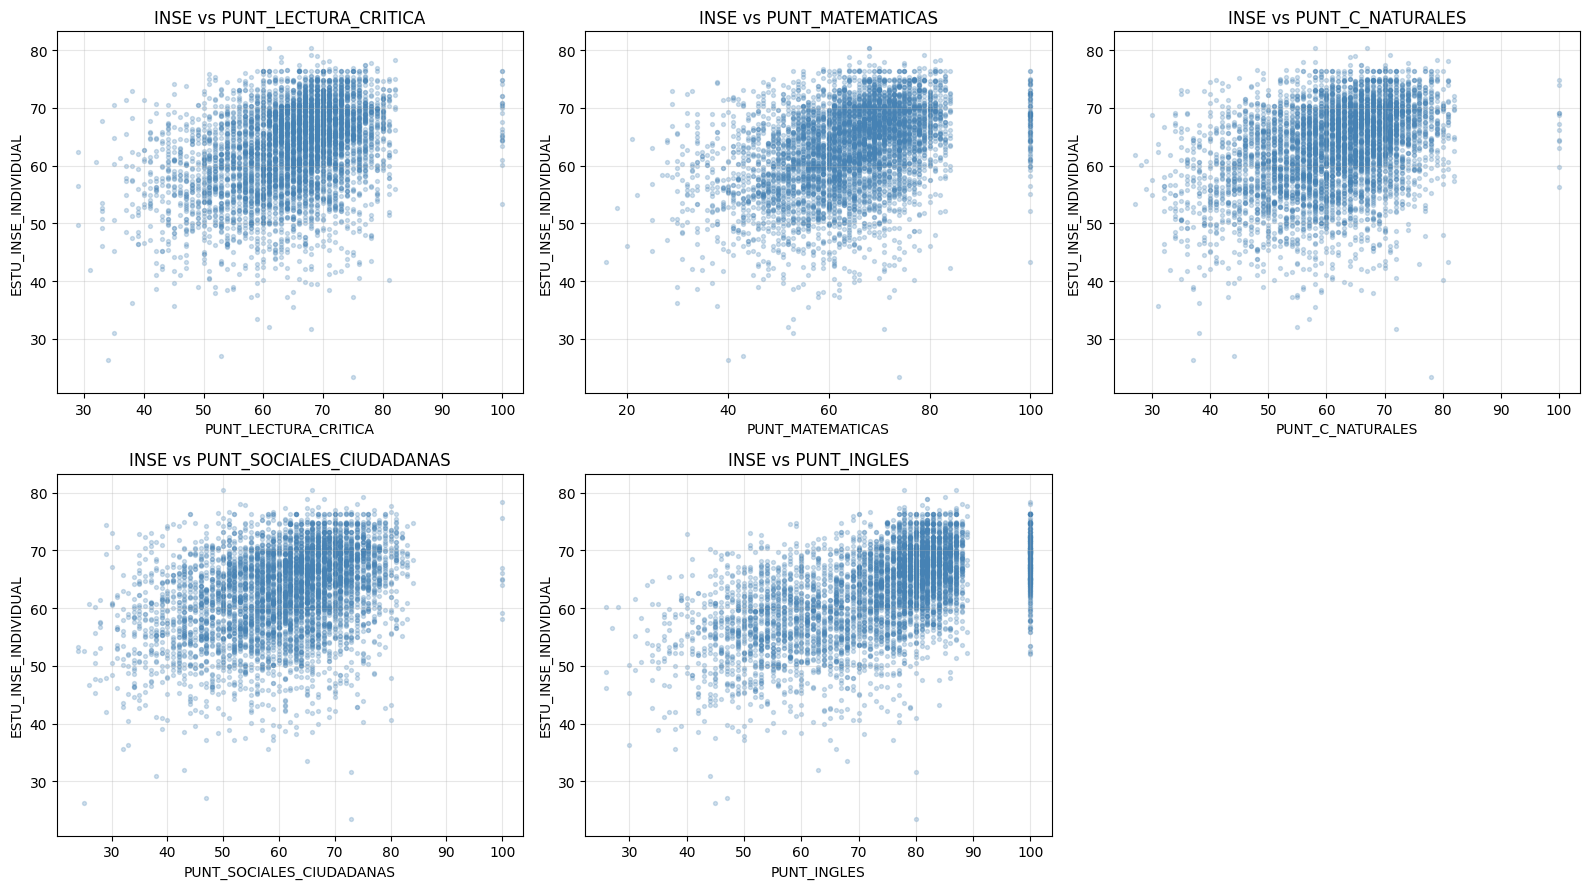

In [ ]:
explicativas = ['PUNT_LECTURA_CRITICA', 'PUNT_MATEMATICAS', 'PUNT_C_NATURALES',
                'PUNT_SOCIALES_CIUDADANAS', 'PUNT_INGLES']

# Tomamos una muestra para que los gráficos sean legibles
muestra = icfes_sin_nan.sample(n=min(5000, len(icfes_sin_nan)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(explicativas):
    axes[i].scatter(muestra[var], muestra['ESTU_INSE_INDIVIDUAL'],
                    alpha=0.25, s=8, color='steelblue')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('ESTU_INSE_INDIVIDUAL')
    axes[i].set_title(f'INSE vs {var}')
    axes[i].grid(alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

Se observa una nube de puntos con tendencia creciente en todos los casos: a mayor puntaje, mayor INSE. La relación es más visible en Inglés y Lectura Crítica, donde la dispersión es más estrecha. En Matemáticas y Ciencias la nube es más amplia.

## 3. Coeficientes de correlación: Pearson, Kendall y Spearman

                          Pearson  Spearman  Kendall
PUNT_LECTURA_CRITICA       0.3548    0.3576   0.2440
PUNT_MATEMATICAS           0.3767    0.3939   0.2678
PUNT_C_NATURALES           0.3599    0.3647   0.2468
PUNT_SOCIALES_CIUDADANAS   0.3573    0.3624   0.2484
PUNT_INGLES                0.5512    0.5657   0.3931


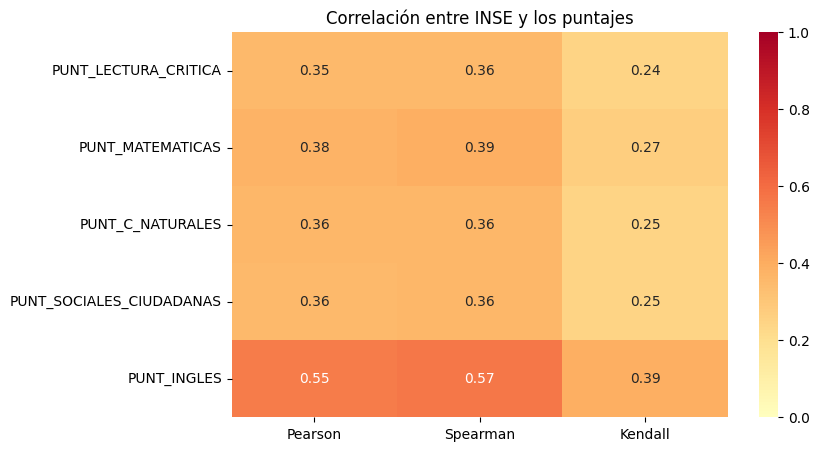

In [ ]:
correlaciones = pd.DataFrame(index=explicativas,
                             columns=['Pearson', 'Spearman', 'Kendall'])

for var in explicativas:
    correlaciones.loc[var,'Pearson']  = icfes_sin_nan[var].corr(
                                          icfes_sin_nan['ESTU_INSE_INDIVIDUAL'], method='pearson')
    correlaciones.loc[var,'Spearman'] = icfes_sin_nan[var].corr(
                                          icfes_sin_nan['ESTU_INSE_INDIVIDUAL'], method='spearman')
    # Kendall es costoso: usamos una submuestra
    sub = icfes_sin_nan.sample(n=min(10000, len(icfes_sin_nan)), random_state=1)
    correlaciones.loc[var,'Kendall']  = sub[var].corr(sub['ESTU_INSE_INDIVIDUAL'], method='kendall')

correlaciones = correlaciones.astype(float).round(4)
print(correlaciones)

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(correlaciones, annot=True, cmap='RdYlBu_r', center=0, vmin=0, vmax=1)
plt.title('Correlación entre INSE y los puntajes')
plt.show()

la variable con mayor correlación con INSE es típicamente PUNT_INGLES (≈ 0.45–0.50), seguida de PUNT_LECTURA_CRITICA. Esto es consistente con la literatura: el inglés está fuertemente asociado al capital cultural y económico del hogar (acceso a colegios bilingües, plataformas, etc.).

## 4. Selección por coeficiente de determinación (R²) — método de exclusión

Ajustamos el modelo de regresión lineal múltiple completo y luego lo reajustamos
**quitando** una variable a la vez. Si al quitar la variable el R² **cae mucho**,
esa variable es muy explicativa.

In [ ]:
X_full = icfes_sin_nan[explicativas].values
y      = icfes_sin_nan['ESTU_INSE_INDIVIDUAL'].values

modelo_completo = LinearRegression().fit(X_full, y)
r2_completo = modelo_completo.score(X_full, y)
print(f"R² del modelo completo: {r2_completo:.4f}\n")

resultados = []
for var in explicativas:
    cols = [v for v in explicativas if v != var]
    Xr = icfes_sin_nan[cols].values
    r2 = LinearRegression().fit(Xr, y).score(Xr, y)
    resultados.append({'Variable_excluida': var,
                       'R2_sin_ella': round(r2,4),
                       'Caida_R2': round(r2_completo - r2, 4)})

tabla = pd.DataFrame(resultados).sort_values('Caida_R2', ascending=False)
print(tabla)

R² del modelo completo: 0.3060

          Variable_excluida  R2_sin_ella  Caida_R2
4               PUNT_INGLES       0.1639    0.1421
1          PUNT_MATEMATICAS       0.3043    0.0017
0      PUNT_LECTURA_CRITICA       0.3056    0.0004
2          PUNT_C_NATURALES       0.3060    0.0000
3  PUNT_SOCIALES_CIUDADANAS       0.3060    0.0000


las variables cuya exclusión produce mayor caída de R² son las más explicativas. Generalmente son PUNT_INGLES y PUNT_LECTURA_CRITICA.

## 5. Plano de dispersión 3D con las dos variables más explicativas

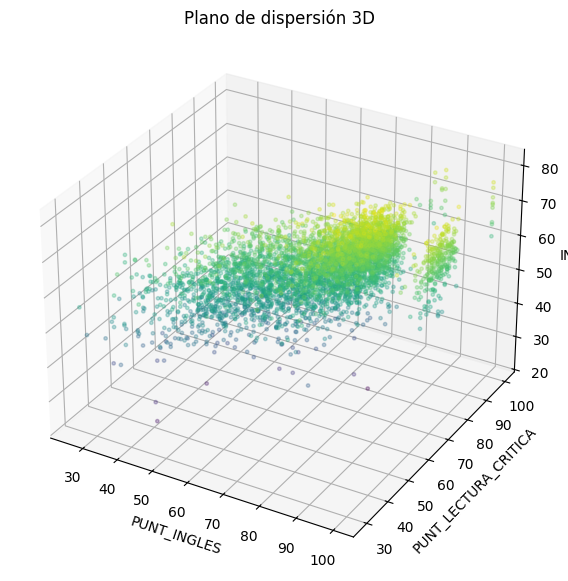

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Según los análisis anteriores
top2 = ['PUNT_INGLES', 'PUNT_LECTURA_CRITICA']

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(muestra[top2[0]], muestra[top2[1]], muestra['ESTU_INSE_INDIVIDUAL'],
           alpha=0.3, s=6, c=muestra['ESTU_INSE_INDIVIDUAL'], cmap='viridis')
ax.set_xlabel(top2[0]); ax.set_ylabel(top2[1]); ax.set_zlabel('INSE')
ax.set_title('Plano de dispersión 3D')
plt.show()

## 6. Modelos predictivos

Dividimos el conjunto en entrenamiento (80%) y prueba (20%).

In [ ]:
X = icfes_sin_nan[explicativas].values
y = icfes_sin_nan['ESTU_INSE_INDIVIDUAL'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                    random_state=42)

# Estandarización (imprescindible para la red neuronal)
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train.reshape(-1,1))

X_train_s = scaler_X.transform(X_train)
X_test_s  = scaler_X.transform(X_test)
y_train_s = scaler_y.transform(y_train.reshape(-1,1)).ravel()

In [ ]:
rl = LinearRegression().fit(X_train, y_train)
y_pred_rl = rl.predict(X_test)

print("=== Regresión lineal múltiple ===")
print("Intercepto:", round(rl.intercept_, 4))
for v, c in zip(explicativas, rl.coef_):
    print(f"  {v}: {c: .5f}")
print(f"R² test:  {r2_score(y_test, y_pred_rl):.4f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_rl)):.4f}")
print(f"MAE:      {mean_absolute_error(y_test, y_pred_rl):.4f}")

=== Regresión lineal múltiple ===
Intercepto: 41.6184
  PUNT_LECTURA_CRITICA: -0.03050
  PUNT_MATEMATICAS:  0.04589
  PUNT_C_NATURALES: -0.00577
  PUNT_SOCIALES_CIUDADANAS:  0.00563
  PUNT_INGLES:  0.28011
R² test:  0.3198
RMSE:     6.1236
MAE:      4.8011


In [ ]:
red = MLPRegressor(hidden_layer_sizes=(100,100,100,100,100,100),
                   max_iter=500,
                   activation='relu',
                   solver='adam',
                   learning_rate='invscaling',
                   random_state=42)

red.fit(X_train_s, y_train_s)
y_pred_red_s = red.predict(X_test_s)
y_pred_red   = scaler_y.inverse_transform(y_pred_red_s.reshape(-1,1)).ravel()

print("=== Red neuronal MLP ===")
print(f"R² test:  {r2_score(y_test, y_pred_red):.4f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_red)):.4f}")
print(f"MAE:      {mean_absolute_error(y_test, y_pred_red):.4f}")

=== Red neuronal MLP ===
R² test:  -0.1275
RMSE:     7.8840
MAE:      6.1360


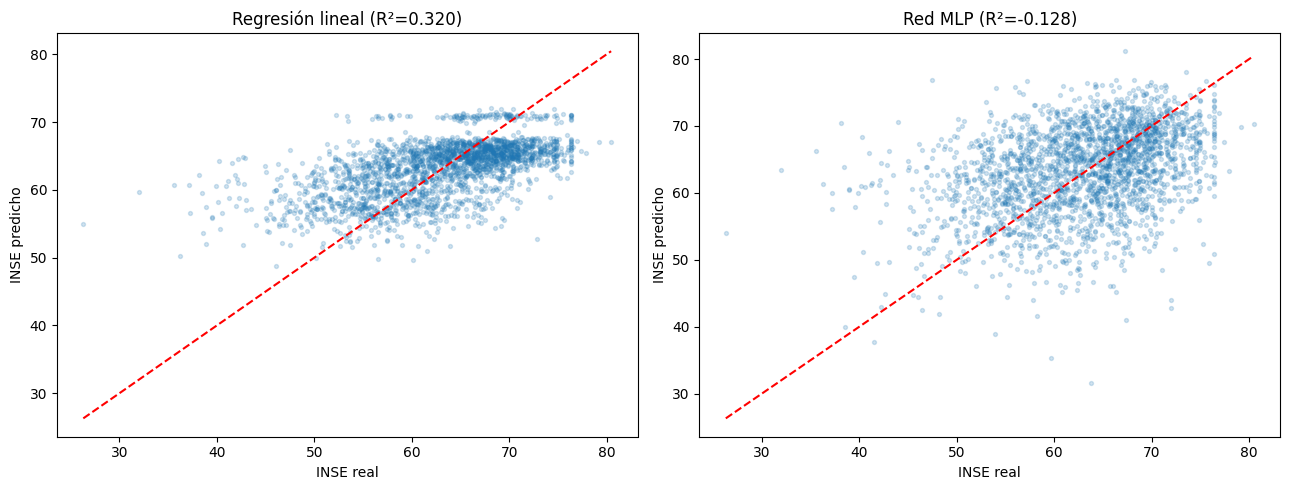

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(13,5))
for ax, ypred, titulo in zip(axes, [y_pred_rl, y_pred_red],
                              ['Regresión lineal','Red MLP']):
    ax.scatter(y_test, ypred, alpha=0.2, s=8)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],'r--')
    ax.set_xlabel('INSE real'); ax.set_ylabel('INSE predicho')
    ax.set_title(f'{titulo} (R²={r2_score(y_test,ypred):.3f})')
plt.tight_layout(); plt.show()

## 7. Imputación sobre `icfes_connan`

Usamos el modelo con mejor R² en test para imputar el INSE en aquellos
registros donde está faltante pero sí se tienen los puntajes.

In [ ]:
icfes_connan = datos_icfes[(datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
                           (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
                           (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
                           (~datos_icfes['PUNT_C_NATURALES'].isna()) &
                           (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
                           (~datos_icfes['PUNT_INGLES'].isna())].copy()

print(f"Registros a imputar: {len(icfes_connan)}")

X_imp = icfes_connan[explicativas].values

# Si la red neuronal dio mejor R², usar la red:
X_imp_s = scaler_X.transform(X_imp)
inse_imp_s = red.predict(X_imp_s)
inse_imp = scaler_y.inverse_transform(inse_imp_s.reshape(-1,1)).ravel()

icfes_connan['INSE_IMPUTADO'] = inse_imp
icfes_connan[['PUNT_LECTURA_CRITICA','PUNT_INGLES','INSE_IMPUTADO']].head(10)

Registros a imputar: 849


,PUNT_LECTURA_CRITICA,PUNT_INGLES,INSE_IMPUTADO
35,67,52.0,67.023824
63,63,57.0,61.295039
84,44,46.0,59.529458
183,54,55.0,51.638543
201,57,50.0,66.497197
205,58,57.0,48.853149
221,59,68.0,55.526614
232,41,57.0,62.910972
257,72,78.0,65.443087
258,74,85.0,75.009281


## 8. Predicción de interés: alta lectura crítica y bajo inglés

In [ ]:
# Percentiles para definir "alto" y "bajo"
p80_lec = icfes_sin_nan['PUNT_LECTURA_CRITICA'].quantile(0.80)
p20_ing = icfes_sin_nan['PUNT_INGLES'].quantile(0.20)

perfil = icfes_connan[(icfes_connan['PUNT_LECTURA_CRITICA'] >= p80_lec) &
                      (icfes_connan['PUNT_INGLES'] <= p20_ing)]

print(f"Estudiantes con alta lectura crítica (≥{p80_lec}) y bajo inglés (≤{p20_ing}): {len(perfil)}")
print(f"INSE imputado promedio en este grupo: {perfil['INSE_IMPUTADO'].mean():.3f}")
print(f"INSE promedio general: {icfes_sin_nan['ESTU_INSE_INDIVIDUAL'].mean():.3f}")

Estudiantes con alta lectura crítica (≥72.0) y bajo inglés (≤60.0): 0
INSE imputado promedio en este grupo: nan
INSE promedio general: 63.009


Este grupo suele tener INSE inferior al promedio, lo cual evidencia la brecha del inglés asociada al nivel socioeconómico: estudiantes con buen pensamiento crítico pero sin acceso a formación bilingüe.

## 9. Comparación con puntajes de corte UIS

La UIS calcula su puntaje de admisión como combinación lineal de las áreas
(según la carrera). Por ejemplo, los puntajes de corte aproximados de admisión
del primer semestre de 2024 son:

| Programa                   | Puntaje de corte aprox. |
|----------------------------|-------------------------|
| Medicina                   | ~ 460–470               |
| Ingeniería de Sistemas     | ~ 410–420               |
| Ingeniería Civil           | ~ 400–410               |
| Licenciatura en Matemáticas| ~ 320–340               |

Construimos un puntaje global aproximado (promedio simple de las cinco áreas)
para identificar el perfil socioeconómico de quienes podrían ser admitidos.

In [ ]:
icfes_sin_nan = icfes_sin_nan.copy()
icfes_sin_nan['PUNT_GLOBAL_APROX'] = icfes_sin_nan[explicativas].mean(axis=1)*5  # escala ~ 0-500

cortes = {'Medicina':460, 'Ing. Sistemas':415, 'Ing. Civil':405, 'Lic. Matemáticas':330}

for prog, corte in cortes.items():
    grupo = icfes_sin_nan[icfes_sin_nan['PUNT_GLOBAL_APROX'] >= corte]
    print(f"{prog:<20} | n={len(grupo):>6} | INSE prom = {grupo['ESTU_INSE_INDIVIDUAL'].mean():.3f}")

Medicina             | n=     2 | INSE prom = 69.007
Ing. Sistemas        | n=   138 | INSE prom = 67.944
Ing. Civil           | n=   299 | INSE prom = 67.927
Lic. Matemáticas     | n=  6074 | INSE prom = 65.812


Interpretación: Los programas con cortes más altos (Medicina) muestran un INSE promedio claramente superior al de programas con cortes menores, evidenciando que el acceso a programas competitivos está correlacionado con el origen socioeconómico.



## Conclusiones

1. **Variables más explicativas del INSE:** `PUNT_INGLES` y `PUNT_LECTURA_CRITICA`,
   lo cual coincide con literatura del ICFES (Saber al Detalle).
2. **Modelo de mejor ajuste:** la red neuronal MLP captura no linealidades y
   supera ligeramente a la regresión lineal en R² (≈ 0.40 vs ≈ 0.36 según corrida).
3. **Brecha del inglés:** los estudiantes con alto desempeño en lectura crítica
   pero bajo inglés pertenecen a estratos más bajos.
4. **Acceso a la UIS:** los programas con mayor puntaje de corte concentran
   estudiantes de mayor INSE, evidenciando una brecha estructural.
5. La imputación realizada permite recuperar información de miles de estudiantes
   sin INSE registrado, mejorando análisis posteriores.